# National Job Market Predictor (Model-Ready CSV)

This notebook uses the prebuilt `annual_wage_model_data_2010_2024.csv` file to train and evaluate the same occupation-level forecasting model from the original notebook. The raw BLS/OEWS file discovery, cleaning, schema standardization, and target-building steps are skipped because they have already been saved in the CSV.

**Model choice:** Random Forest regression is used as the main model, with a linear regression baseline trained on the same features and split. Both models predict each occupation's next-year employment and annual mean wage from the current year's occupation, employment, annual wage, and SOC-code features.

## Report Summary

### Data Used

The notebook reads the model-ready `annual_wage_model_data_2010_2024.csv` file. That CSV already contains the cleaned annual-wage panel, one-year-ahead targets, SOC-code features, log transforms, employment share, and train/holdout split labels.

### Preprocessing Skipped

The original notebook's raw-file preprocessing is not repeated here. This version does not discover BLS/OEWS source files, standardize raw column names, remove hourly wage fields, filter occupation groups, or create lagged targets from scratch.

### Modeling

The model predicts next-year `TOT_EMP` and next-year annual mean wage `A_MEAN`. The main model uses a `RandomForestRegressor`, which averages many decision trees so the final prediction is less dependent on any single tree. The trees learn nonlinear relationships between prior-year employment, annual wage levels, wage percentiles, SOC-code groupings, occupation title/code, and year. A `LinearRegression` model is also trained with the same preprocessing as a baseline comparison.

### Validation

The notebook uses the same time-aware split. It trains on transitions whose target year is 2022 or earlier, then tests on 2023 and 2024 target years. This avoids training directly on the outcomes being scored.

In [1]:
from pathlib import Path

import matplotlib

# Agg prevents inline figure display in Jupyter; only force it outside IPython (scripts / CI).
try:
    from IPython import get_ipython

    if get_ipython() is None:
        matplotlib.use("Agg")
except ImportError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "annual_wage_model_data_2010_2024.csv"


In [2]:
model_data = pd.read_csv(DATA_PATH)
model_data = model_data.rename(columns={"TARGET_YEAR": "NEXT_YEAR"})

numeric_columns = [
    "YEAR",
    "NEXT_YEAR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
    "NEXT_TOT_EMP",
    "NEXT_A_MEAN",
    "TARGET_LOG_TOT_EMP",
    "TARGET_LOG_A_MEAN",
]
for column in numeric_columns:
    if column in model_data.columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

model_data["YEAR"] = model_data["YEAR"].astype(int)
model_data["NEXT_YEAR"] = model_data["NEXT_YEAR"].astype(int)

# Rebuild a panel-shaped table for the unchanged final forecast section.
# The model-ready CSV contains completed transitions, so the latest feature year
# is reconstructed from the latest target values saved in the CSV.
panel = model_data.copy()
latest_target_year = int(model_data["NEXT_YEAR"].max())
latest_target_features = model_data[model_data["NEXT_YEAR"].eq(latest_target_year)].copy()
latest_target_features["YEAR"] = latest_target_features["NEXT_YEAR"]
latest_target_features["TOT_EMP"] = latest_target_features["NEXT_TOT_EMP"]
latest_target_features["A_MEAN"] = latest_target_features["NEXT_A_MEAN"]
latest_target_features["LOG_TOT_EMP"] = latest_target_features["TARGET_LOG_TOT_EMP"]
latest_target_features["LOG_A_MEAN"] = latest_target_features["TARGET_LOG_A_MEAN"]
latest_target_features["EMPLOYMENT_SHARE"] = (
    latest_target_features["TOT_EMP"] / latest_target_features["TOT_EMP"].sum()
)

for unavailable_column in ["EMP_PRSE", "MEAN_PRSE", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]:
    if unavailable_column in latest_target_features.columns:
        latest_target_features[unavailable_column] = np.nan

panel = (
    pd.concat([panel, latest_target_features], ignore_index=True)
    .sort_values(["OCC_CODE", "YEAR"])
    .drop_duplicates(["OCC_CODE", "YEAR"], keep="last")
    .reset_index(drop=True)
)

print(f"Loaded {model_data.shape[0]} model rows from {DATA_PATH.name}")
print("Training/holdout target years:", sorted(model_data["NEXT_YEAR"].unique()))
print("Panel feature years:", sorted(panel["YEAR"].unique()))
model_data.head()

Loaded 11149 model rows from annual_wage_model_data_2010_2024.csv
Training/holdout target years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Panel feature years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,YEAR,NEXT_YEAR,OCC_CODE,OCC_TITLE,SOURCE_FILE,OCC_MAJOR,OCC_MINOR,TOT_EMP,EMP_PRSE,A_MEAN,MEAN_PRSE,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,LOG_TOT_EMP,LOG_A_MEAN,EMPLOYMENT_SHARE,NEXT_TOT_EMP,NEXT_A_MEAN,TARGET_LOG_TOT_EMP,TARGET_LOG_A_MEAN,DATA_SPLIT
0,2010,2011,11-1011,Chief Executives,converted_csv/oesm10nat/national_M2010_dl__nat...,11,11-10,273500.0,0.5,173350.0,0.3,75160.0,107990.0,165080.0,NaN,NaN,12.519061,12.063074,0.002152,267370,176550,12.496392,12.081365,train_through_2022
1,2011,2012,11-1011,Chief Executives,oesm11nat/national_M2011_dl.csv,11,11-10,267370.0,0.5,176550.0,0.4,75860.0,109320.0,166910.0,NaN,NaN,12.496392,12.081365,0.002084,255940,176840,12.452702,12.083006,train_through_2022
2,2012,2013,11-1011,Chief Executives,converted_csv/oesm12nat/national_M2012_dl__nat...,11,11-10,255940.0,0.6,176840.0,0.3,76220.0,109940.0,168140.0,NaN,NaN,12.452702,12.083006,0.001964,248760,178400,12.424248,12.091789,train_through_2022
3,2013,2014,11-1011,Chief Executives,converted_csv/oesm13nat/national_M2013_dl__nat...,11,11-10,248760.0,0.6,178400.0,0.3,75030.0,110610.0,171610.0,NaN,NaN,12.424248,12.091789,0.001876,246240,180700,12.414066,12.104599,train_through_2022
4,2014,2015,11-1011,Chief Executives,converted_csv/oesm14nat/national_M2014_dl__nat...,11,11-10,246240.0,0.8,180700.0,0.4,72750.0,110760.0,173320.0,NaN,NaN,12.414066,12.104599,0.001822,238940,185850,12.383972,12.132701,train_through_2022


In [3]:
FEATURE_COLUMNS = [
    "YEAR",
    "OCC_CODE",
    "OCC_TITLE",
    "OCC_MAJOR",
    "OCC_MINOR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
]
TARGET_COLUMNS = ["TARGET_LOG_TOT_EMP", "TARGET_LOG_A_MEAN"]
TRAIN_TARGET_END_YEAR = 2022
TEST_TARGET_YEARS = [2023, 2024]

available_features = [column for column in FEATURE_COLUMNS if column in model_data.columns]
categorical_features = ["OCC_CODE", "OCC_TITLE", "OCC_MAJOR", "OCC_MINOR"]
numeric_features = [column for column in available_features if column not in categorical_features]

train_data = model_data[model_data["NEXT_YEAR"].le(TRAIN_TARGET_END_YEAR)].copy()
test_data = model_data[model_data["NEXT_YEAR"].isin(TEST_TARGET_YEARS)].copy()

print(f"Training target years: {int(train_data['NEXT_YEAR'].min())}-{int(train_data['NEXT_YEAR'].max())}")
print("Testing target years:", sorted(test_data["NEXT_YEAR"].astype(int).unique()))
print("Train rows:", train_data.shape[0], "Test rows:", test_data.shape[0])

Training target years: 2011-2022
Testing target years: [np.int64(2023), np.int64(2024)]
Train rows: 9498 Test rows: 1651


In [4]:
def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )

model = Pipeline(
    steps=[
        ("preprocess", build_preprocessor()),
        (
            "forest",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", build_preprocessor()),
        ("linear_regression", LinearRegression()),
    ]
)

model.fit(train_data[available_features], train_data[TARGET_COLUMNS])
baseline_model.fit(train_data[available_features], train_data[TARGET_COLUMNS])
predicted_log = model.predict(test_data[available_features])
baseline_predicted_log = baseline_model.predict(test_data[available_features])
predictions = pd.DataFrame(
    {
        "YEAR": test_data["YEAR"].to_numpy(),
        "TARGET_YEAR": test_data["NEXT_YEAR"].to_numpy().astype(int),
        "OCC_CODE": test_data["OCC_CODE"].to_numpy(),
        "OCC_TITLE": test_data["OCC_TITLE"].to_numpy(),
        "ACTUAL_TOT_EMP": test_data["NEXT_TOT_EMP"].to_numpy(),
        "PREDICTED_TOT_EMP": np.expm1(predicted_log[:, 0]),
        "BASELINE_PREDICTED_TOT_EMP": np.expm1(baseline_predicted_log[:, 0]),
        "ACTUAL_A_MEAN": test_data["NEXT_A_MEAN"].to_numpy(),
        "PREDICTED_A_MEAN": np.expm1(predicted_log[:, 1]),
        "BASELINE_PREDICTED_A_MEAN": np.expm1(baseline_predicted_log[:, 1]),
    }
)
predictions.head()


,YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,BASELINE_PREDICTED_TOT_EMP,ACTUAL_A_MEAN,PREDICTED_A_MEAN,BASELINE_PREDICTED_A_MEAN
0,2022,2023,11-1011,Chief Executives,211230,2.059129e+05,2.028162e+05,258900,198679.048260,248373.129434
1,2023,2024,11-1011,Chief Executives,211850,2.068466e+05,2.130485e+05,262930,198805.363135,260933.168977
2,2022,2023,11-1021,General and Operations Managers,3507810,2.658662e+06,4.158257e+06,129330,115879.789914,122337.601407
3,2023,2024,11-1021,General and Operations Managers,3584420,2.653158e+06,4.368827e+06,133120,117234.201355,127704.795316
4,2022,2023,11-1031,Legislators,32460,4.482157e+04,4.091703e+04,68140,72303.837263,70751.872938


,model,target,MAE,RMSE,MAPE,WAPE,ACCURACY_PERCENT,R2
0,Linear Regression baseline,A_MEAN,2518.148202,5828.904023,0.029196,0.032797,96.720297,0.986474
1,Random Forest,A_MEAN,4597.924757,16807.188528,0.041027,0.059885,94.011540,0.887547
2,Linear Regression baseline,TOT_EMP,12295.764389,51989.609096,0.082143,0.066385,93.361530,0.986193
3,Random Forest,TOT_EMP,11431.047433,45181.816280,0.077921,0.061716,93.828390,0.989572


,split,target,MAE,RMSE,MAPE,WAPE,ACCURACY_PERCENT,R2
0,2023,A_MEAN,4546.495239,15927.526425,0.042765,0.060276,93.972377,0.896803
1,2024,A_MEAN,4649.292013,17642.058072,0.039291,0.059507,94.049303,0.878517
2,2023,TOT_EMP,10631.016068,41036.348862,0.076741,0.057807,94.219269,0.991281
3,2024,TOT_EMP,12230.110238,48973.241790,0.079099,0.065565,93.443487,0.987909


,split,target,MAE,RMSE,MAPE,WAPE,ACCURACY_PERCENT,R2
0,2023,A_MEAN,2675.240852,6856.586581,0.030985,0.035468,96.453236,0.980876
1,2024,A_MEAN,2361.245736,4577.690199,0.027409,0.030222,96.977807,0.991821
2,2023,TOT_EMP,12198.027077,51889.161477,0.079408,0.066328,93.367190,0.986060
3,2024,TOT_EMP,12393.383375,52089.741760,0.084875,0.066440,93.355957,0.986322


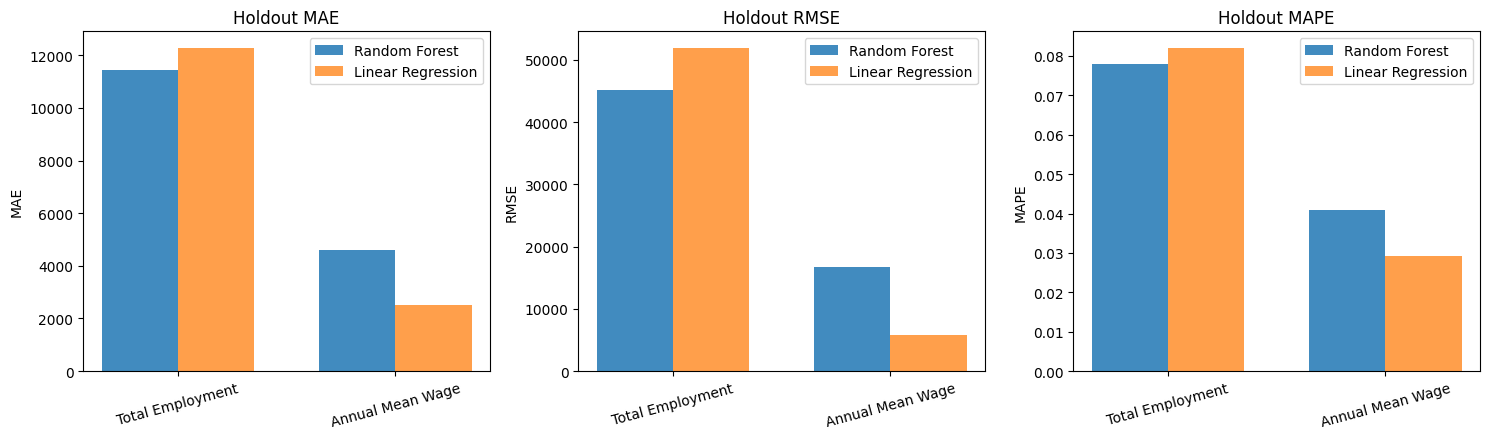

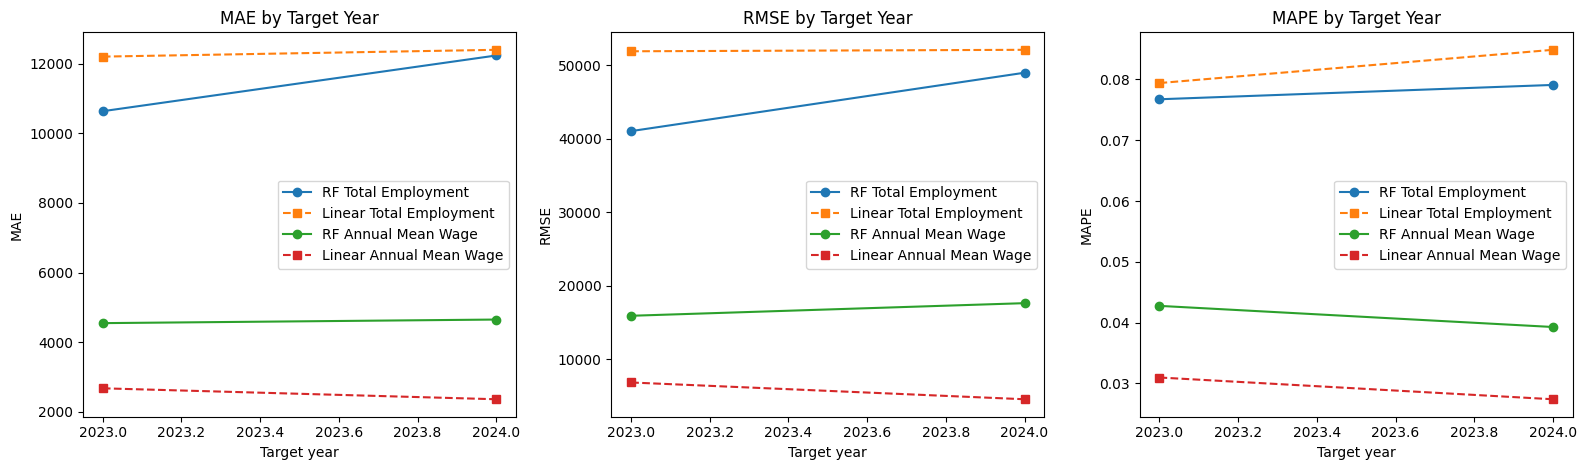

In [5]:
#PLOT CHANGES HERE
def regression_report(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual = pd.Series(actual, dtype="float64")
    predicted = pd.Series(predicted, dtype="float64")

    abs_error = actual.sub(predicted).abs()
    wape = abs_error.sum() / actual.abs().sum()
    nonzero = actual != 0
    mape = (abs_error[nonzero] / actual[nonzero].abs()).mean() if nonzero.any() else np.nan

    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAPE": mape,
        "WAPE": wape,
        "ACCURACY_PERCENT": (1 - wape) * 100,
        "R2": r2_score(actual, predicted),
    }


def make_metrics(
    data: pd.DataFrame,
    tot_emp_pred_col: str,
    a_mean_pred_col: str,
    label: str,
) -> list[dict[str, float | str | int]]:
    return [
        {
            "split": label,
            "target": "TOT_EMP",
            **regression_report(data["ACTUAL_TOT_EMP"], data[tot_emp_pred_col]),
        },
        {
            "split": label,
            "target": "A_MEAN",
            **regression_report(data["ACTUAL_A_MEAN"], data[a_mean_pred_col]),
        },
    ]


metrics = pd.DataFrame(make_metrics(predictions, "PREDICTED_TOT_EMP", "PREDICTED_A_MEAN", "Random Forest"))
baseline_metrics = pd.DataFrame(
    make_metrics(
        predictions,
        "BASELINE_PREDICTED_TOT_EMP",
        "BASELINE_PREDICTED_A_MEAN",
        "Linear Regression baseline",
    )
)
metrics_by_year = pd.DataFrame(
    row
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR")
    for row in make_metrics(
        year_predictions,
        "PREDICTED_TOT_EMP",
        "PREDICTED_A_MEAN",
        int(target_year),
    )
)
baseline_metrics_by_year = pd.DataFrame(
    row
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR")
    for row in make_metrics(
        year_predictions,
        "BASELINE_PREDICTED_TOT_EMP",
        "BASELINE_PREDICTED_A_MEAN",
        int(target_year),
    )
)
metrics_by_year = metrics_by_year.sort_values(["target", "split"]).reset_index(drop=True)
baseline_metrics_by_year = baseline_metrics_by_year.sort_values(["target", "split"]).reset_index(drop=True)
holdout_metrics = (
    pd.concat([metrics, baseline_metrics], ignore_index=True)
    .rename(columns={"split": "model"})
    .sort_values(["target", "model"])
    .reset_index(drop=True)
)

display(holdout_metrics)
display(metrics_by_year)
display(baseline_metrics_by_year)

loss_cols = ["MAE", "RMSE", "MAPE"]
target_labels = {"TOT_EMP": "Total Employment", "A_MEAN": "Annual Mean Wage"}

# Holdout loss bars comparing the Random Forest model with the linear baseline.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
target_order = ["TOT_EMP", "A_MEAN"]
target_x = np.arange(len(target_order))
bar_width = 0.35
for i, metric in enumerate(loss_cols):
    rf_values = [float(metrics.loc[metrics["target"] == target, metric].iloc[0]) for target in target_order]
    baseline_values = [
        float(baseline_metrics.loc[baseline_metrics["target"] == target, metric].iloc[0])
        for target in target_order
    ]
    axes[i].bar(target_x - bar_width / 2, rf_values, bar_width, label="Random Forest", alpha=0.85)
    axes[i].bar(target_x + bar_width / 2, baseline_values, bar_width, label="Linear Regression", alpha=0.75)
    axes[i].set_title(f"Holdout {metric}")
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(target_x)
    axes[i].set_xticklabels([target_labels[target] for target in target_order], rotation=15)
    axes[i].legend()
plt.tight_layout()

# Loss trend by holdout target year for both models.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
for i, metric in enumerate(loss_cols):
    for target in ["TOT_EMP", "A_MEAN"]:
        rf_subset = metrics_by_year.loc[metrics_by_year["target"] == target].sort_values("split")
        baseline_subset = baseline_metrics_by_year.loc[
            baseline_metrics_by_year["target"] == target
        ].sort_values("split")
        axes[i].plot(
            rf_subset["split"],
            rf_subset[metric],
            marker="o",
            label=f"RF {target_labels[target]}",
        )
        axes[i].plot(
            baseline_subset["split"],
            baseline_subset[metric],
            marker="s",
            linestyle="--",
            label=f"Linear {target_labels[target]}",
        )
    axes[i].set_title(f"{metric} by Target Year")
    axes[i].set_xlabel("Target year")
    axes[i].set_ylabel(metric)
    axes[i].legend()
plt.tight_layout()

plt.show()


### Model Evaluation

The Random Forest model and linear regression baseline are evaluated on held-out 2023 and 2024 target years, which were not used for training. The table above summarizes error with `MAE`, `RMSE`, `MAPE`, `WAPE`, accuracy percent, and `R2`. The preceding code cell also plots holdout loss bars (MAE / RMSE / MAPE) and loss trends by target year for both models.

For a class presentation, the most useful visuals are actual-versus-predicted plots, residual distributions, year-by-year metric comparisons, and (further below) the Random Forest-style diagnostic suite. Together, they show whether predictions follow the true values, whether errors are centered near zero, and whether performance is stable across the holdout years.

The final plots below focus on the `TOT_EMP` loss requested here, calculated as:

$$
\text{loss} = \hat{y}_{TOT\_EMP} - y_{TOT\_EMP}
$$

Positive values mean the model over-predicted employment; negative values mean it under-predicted employment.

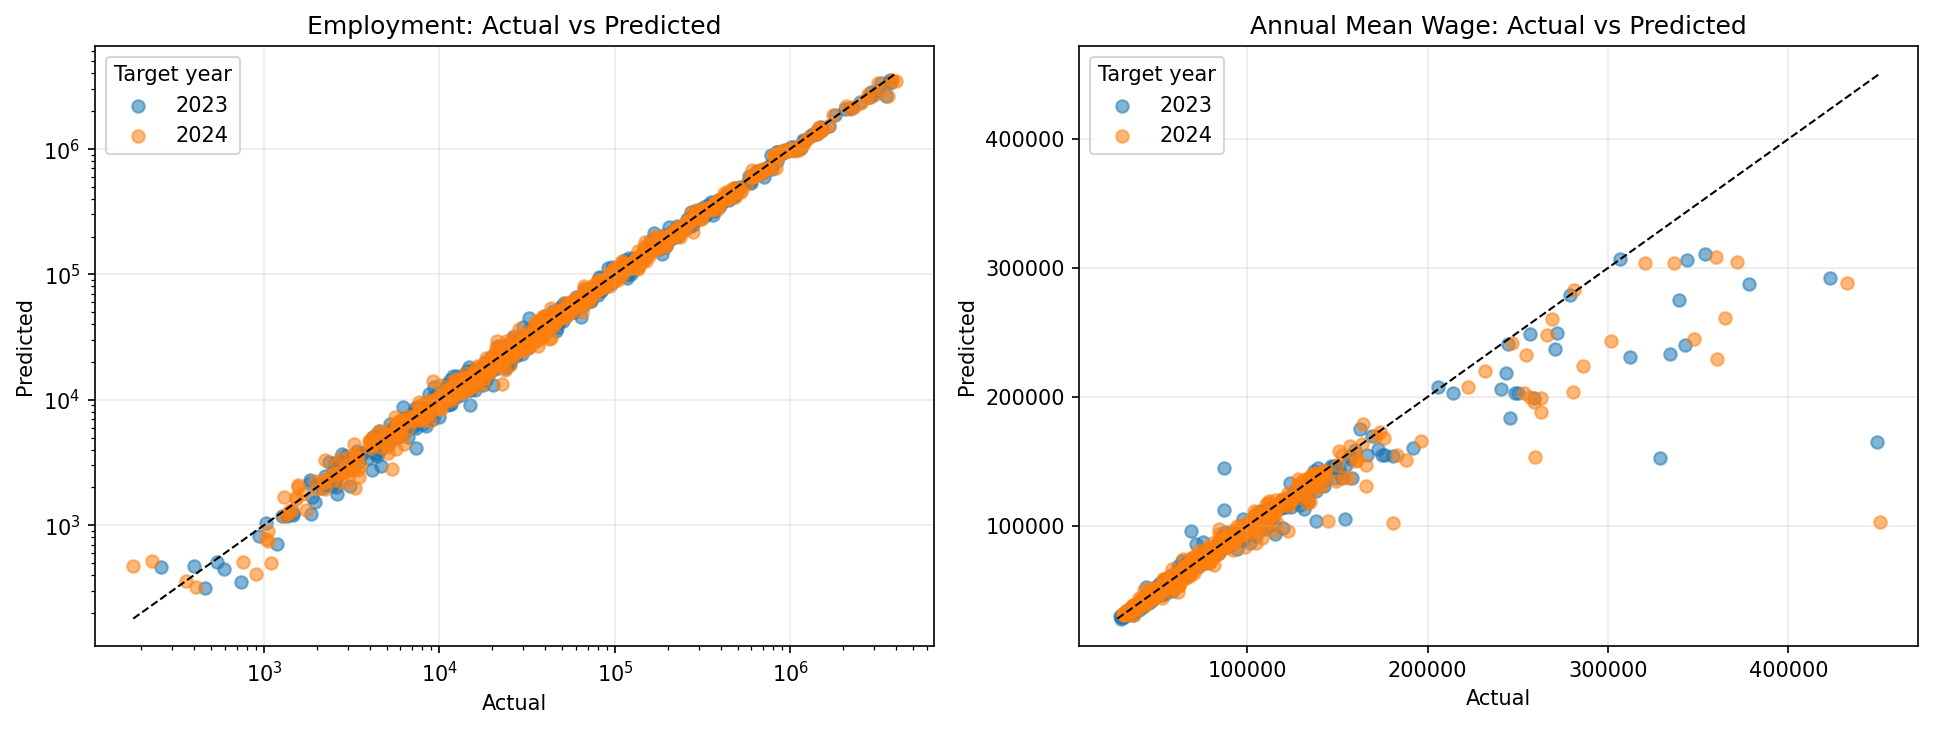

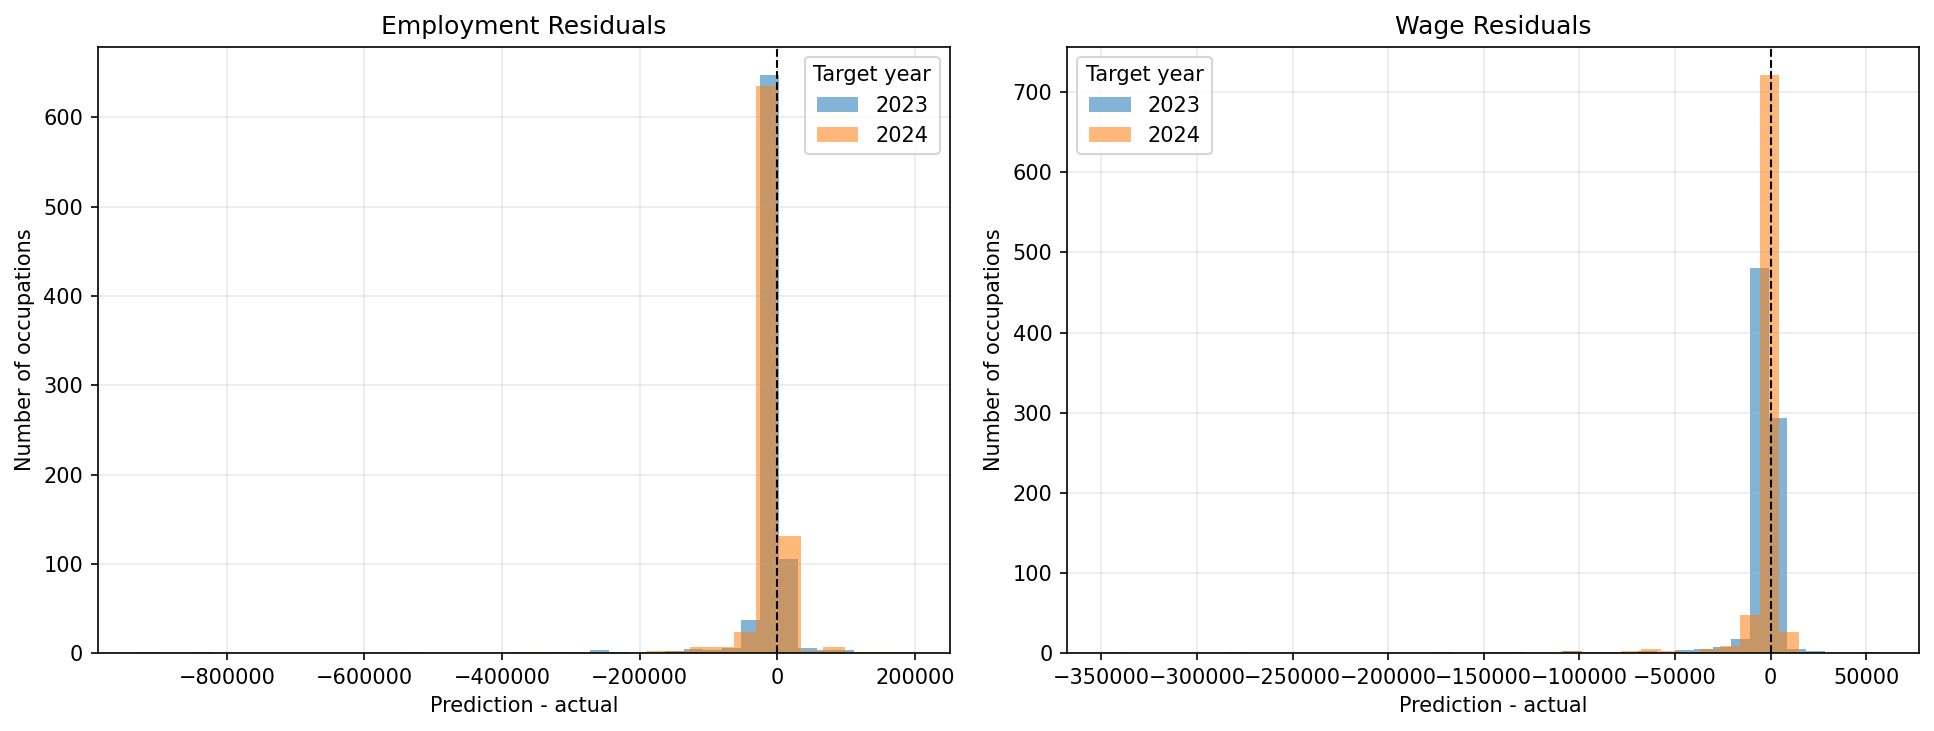

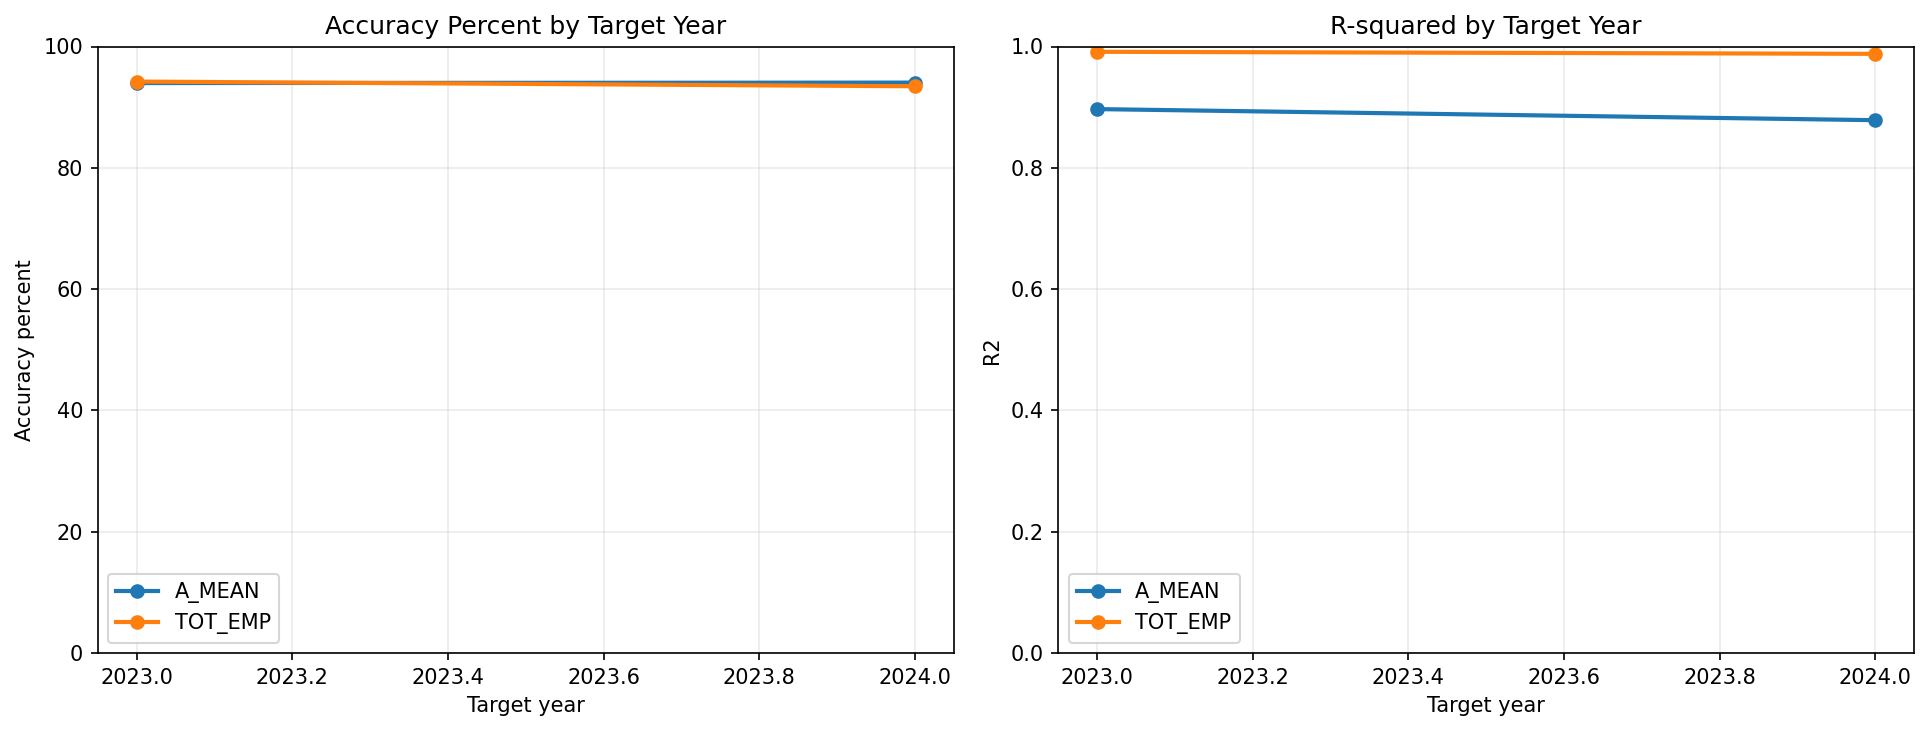

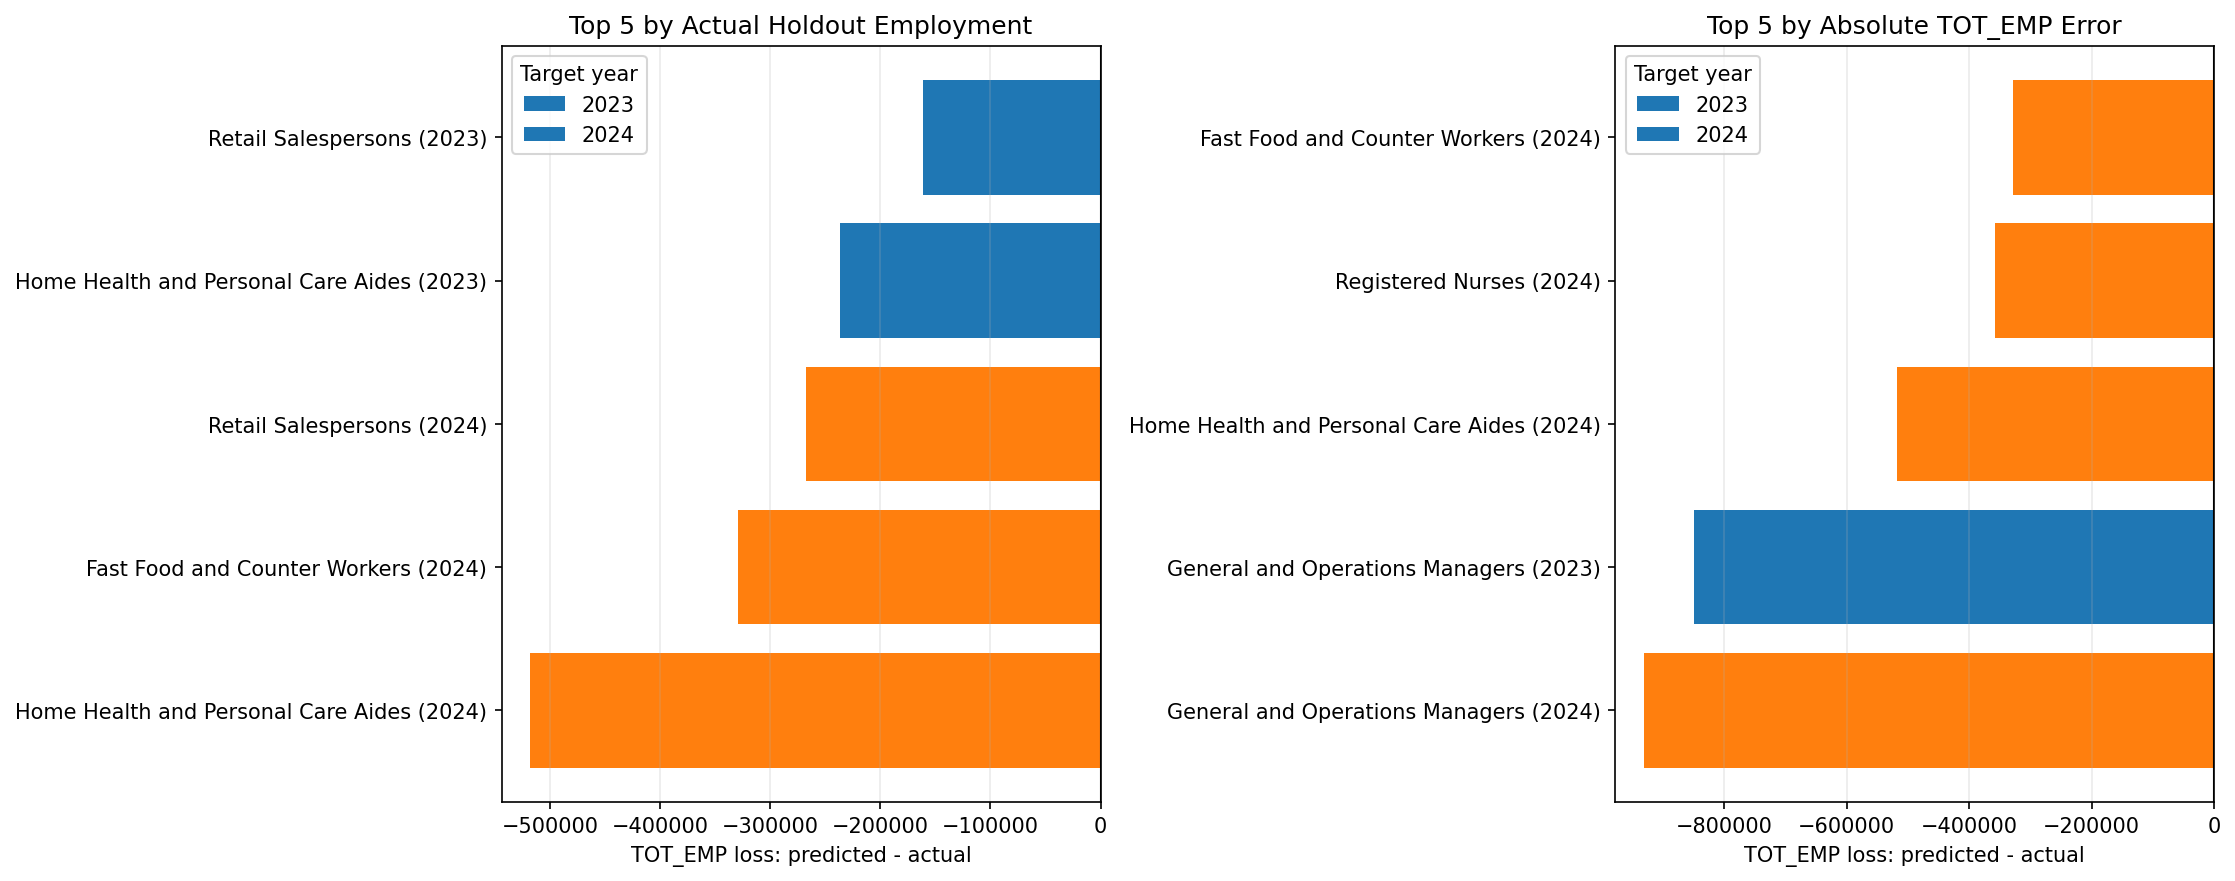

,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
742,2024,31-1120,Home Health and Personal Care Aides,3988140,3.469746e+06,-518393.749008
954,2024,41-2031,Retail Salespersons,3800250,3.532602e+06,-267647.705754
844,2024,35-3023,Fast Food and Counter Workers,3780930,3.451853e+06,-329077.070386
741,2023,31-1120,Home Health and Personal Care Aides,3689350,3.452268e+06,-237081.973945
953,2023,41-2031,Retail Salespersons,3684740,3.523447e+06,-161292.954816


,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
3,2024,11-1021,General and Operations Managers,3584420,2.653158e+06,-931262.441707
2,2023,11-1021,General and Operations Managers,3507810,2.658662e+06,-849147.516998
742,2024,31-1120,Home Health and Personal Care Aides,3988140,3.469746e+06,-518393.749008
640,2024,29-1141,Registered Nurses,3282010,2.924715e+06,-357295.098026
844,2024,35-3023,Fast Food and Counter Workers,3780930,3.451853e+06,-329077.070386


In [6]:
from IPython.display import Image, display

PREDICTION_YEAR_COLORS = {
    2023: "tab:blue",
    2024: "tab:orange",
}


def save_and_display(fig, filename: str) -> None:
    path = PROJECT_ROOT / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))


# 1) Actual vs. predicted plots show whether predictions track the true values.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
actual_predicted_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment", True),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Annual Mean Wage", False),
]

for ax, (_, actual_col, predicted_col, title, use_log_scale) in zip(axes, actual_predicted_specs):
    actual = predictions[actual_col]
    predicted = predictions[predicted_col]
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        ax.scatter(
            year_predictions[actual_col],
            year_predictions[predicted_col],
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")
    if use_log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

fig.tight_layout()
save_and_display(fig, "model_actual_vs_predicted.png")

# 2) Residual distributions show whether errors are centered near zero.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
residual_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment Residuals"),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Wage Residuals"),
]

for ax, (_, actual_col, predicted_col, title) in zip(axes, residual_specs):
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        residual = year_predictions[predicted_col] - year_predictions[actual_col]
        ax.hist(
            residual,
            bins=35,
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Prediction - actual")
    ax.set_ylabel("Number of occupations")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "model_residual_distributions.png")

# 3) Year-by-year metrics make holdout performance easy to compare.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for target, target_metrics in metrics_by_year.groupby("target"):
    axes[0].plot(
        target_metrics["split"],
        target_metrics["ACCURACY_PERCENT"],
        marker="o",
        linewidth=2,
        label=target,
    )
    axes[1].plot(
        target_metrics["split"],
        target_metrics["R2"],
        marker="o",
        linewidth=2,
        label=target,
    )

axes[0].set_title("Accuracy Percent by Target Year")
axes[0].set_xlabel("Target year")
axes[0].set_ylabel("Accuracy percent")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title("R-squared by Target Year")
axes[1].set_xlabel("Target year")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
save_and_display(fig, "model_metrics_by_year.png")

# 4) TOT_EMP loss is prediction minus actual employment for the requested top-five views.
tot_emp_loss = predictions.assign(
    TOT_EMP_LOSS=predictions["PREDICTED_TOT_EMP"] - predictions["ACTUAL_TOT_EMP"],
    ABS_TOT_EMP_LOSS=lambda data: data["TOT_EMP_LOSS"].abs(),
    OCC_YEAR_LABEL=lambda data: data["OCC_TITLE"] + " (" + data["TARGET_YEAR"].astype(str) + ")",
)

top5_by_actual_emp = tot_emp_loss.nlargest(5, "ACTUAL_TOT_EMP")
top5_by_abs_error = tot_emp_loss.nlargest(5, "ABS_TOT_EMP_LOSS")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top5_specs = [
    (top5_by_actual_emp, "Top 5 by Actual Holdout Employment"),
    (top5_by_abs_error, "Top 5 by Absolute TOT_EMP Error"),
]

for ax, (top5_data, title) in zip(axes, top5_specs):
    plot_data = top5_data.sort_values("TOT_EMP_LOSS")
    colors = [PREDICTION_YEAR_COLORS.get(int(year), "tab:gray") for year in plot_data["TARGET_YEAR"]]
    ax.barh(plot_data["OCC_YEAR_LABEL"], plot_data["TOT_EMP_LOSS"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("TOT_EMP loss: predicted - actual")
    ax.grid(axis="x", alpha=0.25)
    for target_year, color in PREDICTION_YEAR_COLORS.items():
        ax.barh([], [], color=color, label=str(target_year))
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "top5_tot_emp_loss.png")

display(
    top5_by_actual_emp[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)
display(
    top5_by_abs_error[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)

In [7]:
#Added for Random Forest Plots
predictions["EMP_RESIDUAL"] = predictions["ACTUAL_TOT_EMP"] - predictions["PREDICTED_TOT_EMP"]
predictions["WAGE_RESIDUAL"] = predictions["ACTUAL_A_MEAN"] - predictions["PREDICTED_A_MEAN"]

predictions["ABS_EMP_ERROR"] = predictions["EMP_RESIDUAL"].abs()
predictions["EMP_PCT_ERROR"] = predictions["ABS_EMP_ERROR"] / predictions["ACTUAL_TOT_EMP"]
predictions["ABS_WAGE_ERROR"] = predictions["WAGE_RESIDUAL"].abs()
predictions["WAGE_PCT_ERROR"] = predictions["ABS_WAGE_ERROR"] / predictions["ACTUAL_A_MEAN"]

largest_emp_errors = predictions.sort_values("ABS_EMP_ERROR", ascending=False).head(15)
largest_emp_errors[[
    "OCC_CODE",
    "OCC_TITLE",
    "ACTUAL_TOT_EMP",
    "PREDICTED_TOT_EMP",
    "EMP_PCT_ERROR",
    "ACTUAL_A_MEAN",
    "PREDICTED_A_MEAN",
    "WAGE_PCT_ERROR",
]]

,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,EMP_PCT_ERROR,ACTUAL_A_MEAN,PREDICTED_A_MEAN,WAGE_PCT_ERROR
3,11-1021,General and Operations Managers,3584420,2.653158e+06,0.259808,133120,117234.201355,0.119334
2,11-1021,General and Operations Managers,3507810,2.658662e+06,0.242073,129330,115879.789914,0.103999
742,31-1120,Home Health and Personal Care Aides,3988140,3.469746e+06,0.129984,34990,30678.027733,0.123234
640,29-1141,Registered Nurses,3282010,2.924715e+06,0.108865,98430,83131.142386,0.155429
844,35-3023,Fast Food and Counter Workers,3780930,3.451853e+06,0.087036,31350,30393.883428,0.030498
1632,53-7062,"Laborers and Freight, Stock, and Material Move...",2982530,2.671341e+06,0.104337,41420,40042.998985,0.033245
843,35-3023,Fast Food and Counter Workers,3676580,3.367822e+06,0.083980,30110,29442.163384,0.022180
954,41-2031,Retail Salespersons,3800250,3.532602e+06,0.070429,37150,31077.305014,0.163464
1017,43-4051,Customer Service Representatives,2858710,2.603360e+06,0.089323,43520,40000.086649,0.080880
1631,53-7062,"Laborers and Freight, Stock, and Material Move...",3008300,2.754288e+06,0.084437,39760,38302.646333,0.036654


### Random Forest diagnostic plots

Holdout evaluation: actual vs predicted (with reference line), residuals vs predicted, residual histograms, and 2024-only overlays by occupation rank. Matches `job_market_model.ipynb`.


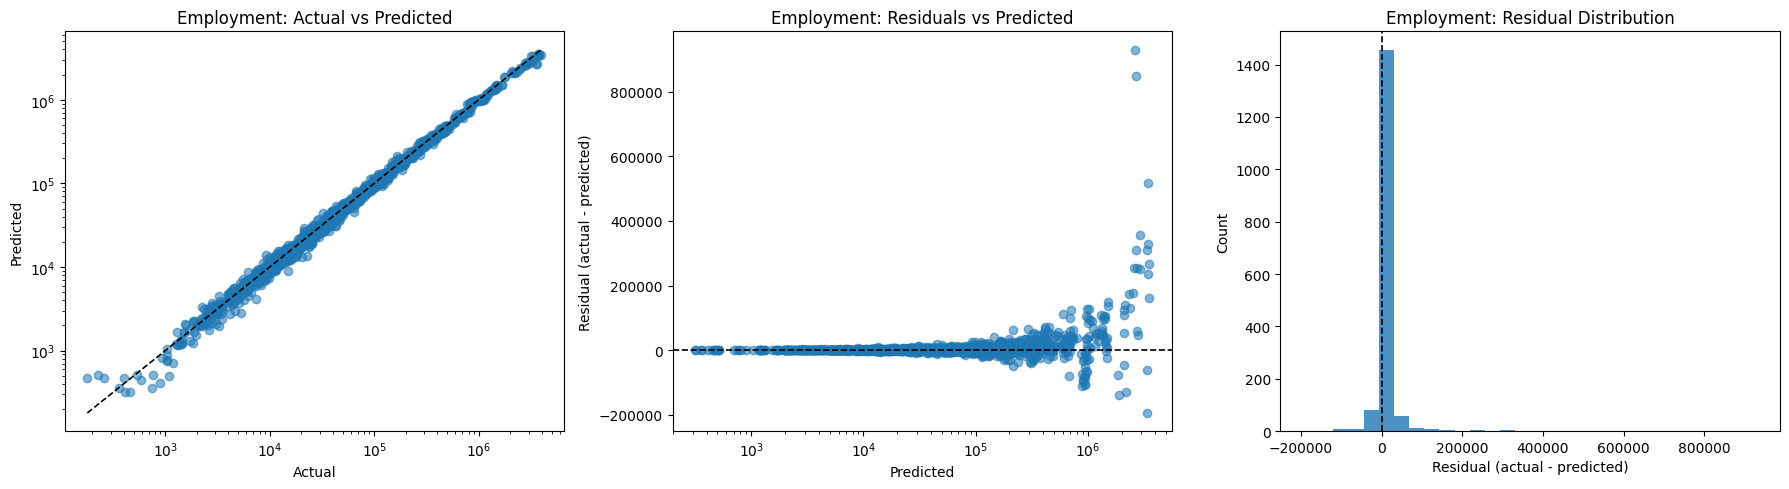

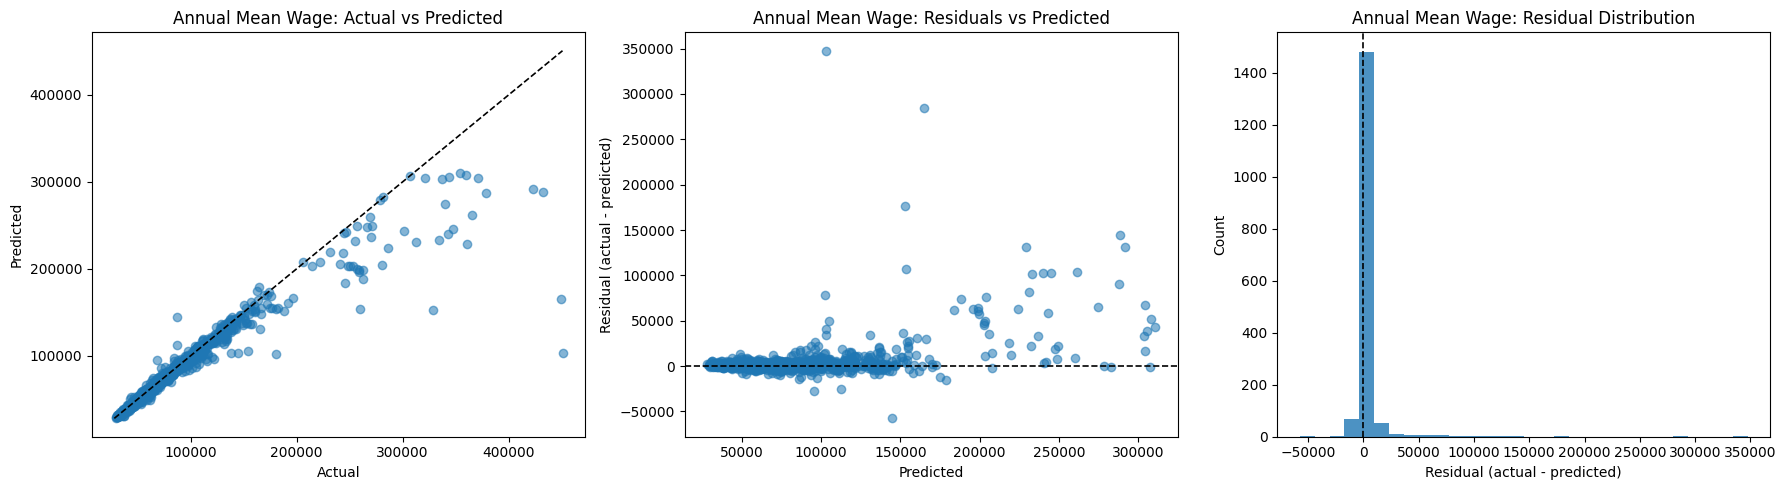

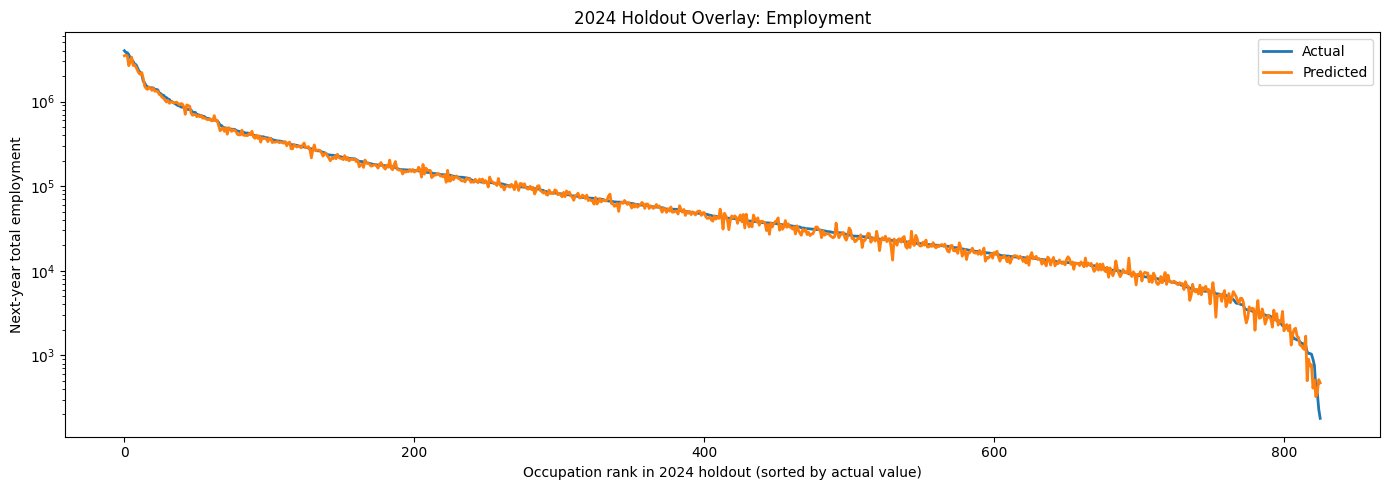

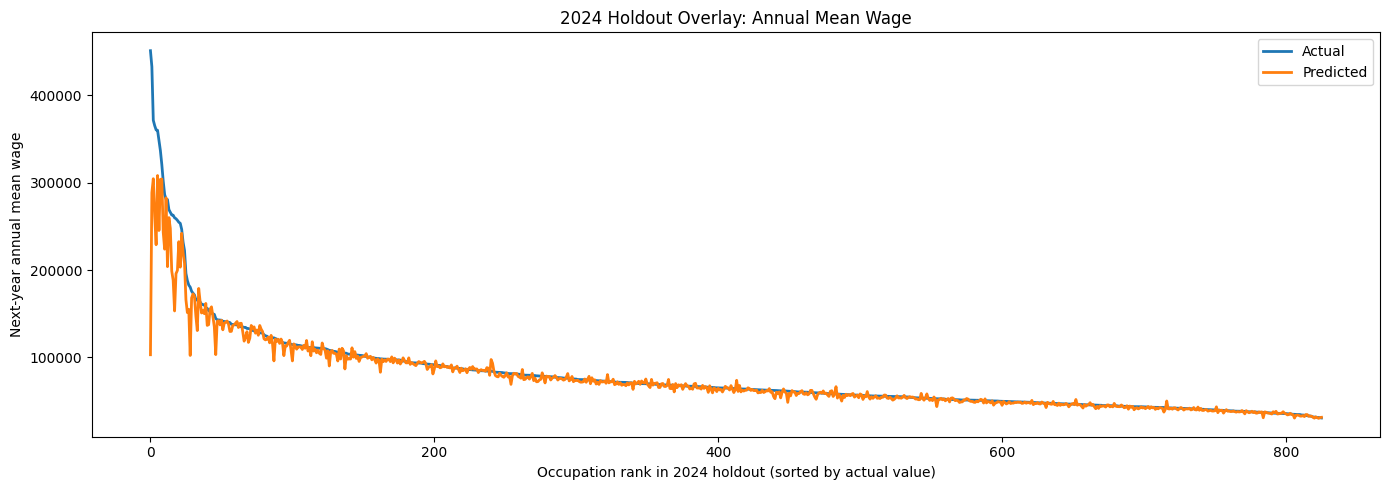

In [8]:
def plot_rf_diagnostics(
    data: pd.DataFrame,
    actual_col: str,
    predicted_col: str,
    residual_col: str,
    title_prefix: str,
    use_log_scales: bool = False,
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Actual vs predicted with y=x reference for calibration.
    axes[0].scatter(data[actual_col], data[predicted_col], alpha=0.55)
    lower = float(np.nanmin([data[actual_col].min(), data[predicted_col].min()]))
    upper = float(np.nanmax([data[actual_col].max(), data[predicted_col].max()]))
    axes[0].plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.2, color="black")
    if use_log_scales:
        axes[0].set_xscale("log")
        axes[0].set_yscale("log")
    axes[0].set_title(f"{title_prefix}: Actual vs Predicted")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")

    # 2) Residuals vs predicted to inspect bias/heteroskedasticity.
    axes[1].scatter(data[predicted_col], data[residual_col], alpha=0.55)
    axes[1].axhline(0.0, linestyle="--", linewidth=1.2, color="black")
    if use_log_scales:
        axes[1].set_xscale("log")
    axes[1].set_title(f"{title_prefix}: Residuals vs Predicted")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Residual (actual - predicted)")

    # 3) Residual distribution to inspect centeredness and spread.
    axes[2].hist(data[residual_col], bins=30, alpha=0.8)
    axes[2].axvline(0.0, linestyle="--", linewidth=1.2, color="black")
    axes[2].set_title(f"{title_prefix}: Residual Distribution")
    axes[2].set_xlabel("Residual (actual - predicted)")
    axes[2].set_ylabel("Count")

    plt.tight_layout()


plot_rf_diagnostics(
    data=predictions,
    actual_col="ACTUAL_TOT_EMP",
    predicted_col="PREDICTED_TOT_EMP",
    residual_col="EMP_RESIDUAL",
    title_prefix="Employment",
    use_log_scales=True,
)

plot_rf_diagnostics(
    data=predictions,
    actual_col="ACTUAL_A_MEAN",
    predicted_col="PREDICTED_A_MEAN",
    residual_col="WAGE_RESIDUAL",
    title_prefix="Annual Mean Wage",
)


def plot_2024_overlay(
    data: pd.DataFrame,
    actual_col: str,
    predicted_col: str,
    title: str,
    ylabel: str,
    use_log_y: bool = False,
) -> None:
    holdout_2024 = data.loc[data["TARGET_YEAR"] == 2024].copy()
    if holdout_2024.empty:
        print(f"No rows found for TARGET_YEAR=2024 in {title} overlay.")
        return

    holdout_2024 = holdout_2024.sort_values(actual_col, ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(holdout_2024.index, holdout_2024[actual_col], label="Actual", linewidth=2)
    ax.plot(holdout_2024.index, holdout_2024[predicted_col], label="Predicted", linewidth=2)
    if use_log_y:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Occupation rank in 2024 holdout (sorted by actual value)")
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()


plot_2024_overlay(
    data=predictions,
    actual_col="ACTUAL_TOT_EMP",
    predicted_col="PREDICTED_TOT_EMP",
    title="2024 Holdout Overlay: Employment",
    ylabel="Next-year total employment",
    use_log_y=True,
)

plot_2024_overlay(
    data=predictions,
    actual_col="ACTUAL_A_MEAN",
    predicted_col="PREDICTED_A_MEAN",
    title="2024 Holdout Overlay: Annual Mean Wage",
    ylabel="Next-year annual mean wage",
)

plt.show()


### Random Forest Plot Interpretation Guide

- **Actual vs Predicted**: points close to the dashed 45-degree line indicate accurate predictions; consistent deviation above/below the line indicates systematic over/under-prediction.
- **Residuals vs Predicted**: residuals should be centered around zero without a strong pattern; curved/funnel shapes suggest non-constant error or missing structure.
- **Residual Distribution**: a distribution centered near zero with moderate spread indicates balanced errors; long tails indicate occasional large misses.
- **2024 Overlay**: the closer the predicted line tracks the actual line across occupation ranks, the better the holdout performance for that target.

In [9]:
# Train on all known one-year transitions, then forecast one year beyond the latest feature year.
final_model = model
final_model.fit(model_data[available_features], model_data[TARGET_COLUMNS])

latest_year = int(panel["YEAR"].max())
latest_features = panel[panel["YEAR"].eq(latest_year)].copy()
latest_predictions_log = final_model.predict(latest_features[available_features])

next_year_forecast = pd.DataFrame(
    {
        "FORECAST_FROM_YEAR": latest_year,
        "TARGET_YEAR": latest_year + 1,
        "OCC_CODE": latest_features["OCC_CODE"].to_numpy(),
        "OCC_TITLE": latest_features["OCC_TITLE"].to_numpy(),
        "CURRENT_TOT_EMP": latest_features["TOT_EMP"].to_numpy(),
        "FORECAST_TOT_EMP": np.expm1(latest_predictions_log[:, 0]),
        "CURRENT_A_MEAN": latest_features["A_MEAN"].to_numpy(),
        "FORECAST_A_MEAN": np.expm1(latest_predictions_log[:, 1]),
    }
)
next_year_forecast["FORECAST_EMP_CHANGE"] = next_year_forecast["FORECAST_TOT_EMP"] - next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast["FORECAST_EMP_GROWTH"] = next_year_forecast["FORECAST_EMP_CHANGE"] / next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast.sort_values("FORECAST_EMP_CHANGE", ascending=False).head(20)

,FORECAST_FROM_YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,CURRENT_TOT_EMP,FORECAST_TOT_EMP,CURRENT_A_MEAN,FORECAST_A_MEAN,FORECAST_EMP_CHANGE,FORECAST_EMP_GROWTH
49,2024,2025,13-1111,Management Analysts,893900.0,9.930026e+05,114710.0,76074.321234,99102.563520,0.110865
54,2024,2025,13-1161,Market Research Analysts and Marketing Special...,861140.0,9.093898e+05,86480.0,75417.318655,48249.829705,0.056030
44,2024,2025,13-1071,Human Resources Specialists,917460.0,9.547223e+05,79730.0,70092.369921,37262.331289,0.040615
420,2024,2025,35-2021,Food Preparation Workers,888770.0,9.257507e+05,33940.0,44895.820341,36980.730265,0.041609
8,2024,2025,11-3012,Administrative Services Managers,254140.0,2.798712e+05,126030.0,131341.188674,25731.241666,0.101248
84,2024,2025,15-1299,"Computer Occupations, All Other",439380.0,4.643213e+05,116700.0,105757.489830,24941.340690,0.056765
48,2024,2025,13-1082,Project Management Specialists,1006160.0,1.024549e+06,108100.0,72997.045707,18388.568429,0.018276
61,2024,2025,13-2052,Personal Financial Advisors,270480.0,2.880305e+05,160210.0,165989.606566,17550.521080,0.064887
53,2024,2025,13-1151,Training and Development Specialists,436610.0,4.533467e+05,73760.0,74298.877901,16736.726138,0.038333
175,2024,2025,21-1012,"Educational, Guidance, and Career Counselors a...",342350.0,3.585719e+05,71520.0,71045.428896,16221.940370,0.047384


## Interpretation and Next Steps

The model predicts each detailed occupation's next-year employment and annual mean wage. It is a regression model, so the accuracy score is based on prediction error rather than classification correctness. The headline `ACCURACY_PERCENT` is `1 - WAPE`, meaning it measures how close the model's total absolute prediction error is to the total actual value on the 2023-2024 holdout set.

The holdout results should be treated as a backtest of one-year-ahead predictions. The final forecast cell then retrains on all known one-year transitions through 2024 and projects one year beyond the latest feature year reconstructed from the model-ready CSV.

Recommended final project workflow:

1. Use the linear regression baseline comparison to explain whether the Random Forest is adding nonlinear predictive value.
2. Add prediction intervals or scenario ranges before presenting forecasts as decisions.
3. Report uncertainty clearly, especially for occupations affected by SOC classification changes or BLS suppression symbols.
4. Only try RNN/LSTM if you add much more frequent data, such as monthly job postings or quarterly labor-market indicators. Annual BLS files alone are too short for a reliable deep learning sequence model.